In [1]:
%pip install -q requests pydantic python-dotenv pandas matplotlib numpy pymilvus pypdf

Note: you may need to restart the kernel to use updated packages.


In [35]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
import pandas as pd
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents with RAG"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar02-data"), Path("/kaggle/input/seminar02-data/data")]
             if (p / "corpus_2026.jsonl").exists()), Path("data"))
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

In [36]:
DATA

WindowsPath('data')

# Корпус и нарезка

In [37]:
corpus, tasks = load_jsonl("corpus_2026.jsonl"), load_jsonl("fresh_2026.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), tasks[0]

(14,
 530200,
 44,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'What was the sentence given to Asiya Andrabi in March 2026 in India?',
  'answer': 'life imprisonment',
  'evidence': '24 March – A special NIA court sentences Kashmiri separatist Asiya Andrabi to life imprisonment for her involvement in terrorist activities in Kashmir.',
  'page': '2026 in India',
  'url': 'https://en.wikipedia.org/wiki/2026_in_India',
  'agent_ok': True})

In [38]:
def chunk_lines(page):
    chunks, section = [], ""
    for line in page["text"].splitlines():
        line = " ".join(line.split())
        if line.startswith("="):
            section = line.strip('= ')
        elif len(line) > 40:
            chunks.append({"page": page["page"], "section": section, "url" : page["url"], "text": line})
    return chunks

In [39]:
def chunk_chars(page, size=400):
    text = " ".join(page["text"].split())
    return [{"page": page["page"], "section": "", "url": page["url"], "text": text[i:i + size]} for i in range(0, len(text), size)]

In [40]:
line_chunks = [c for p in corpus for c in chunk_lines(p)]
char_chunks = [c for p in corpus for c in chunk_chars(p)]
len(line_chunks), len(char_chunks), line_chunks[100]

(3345,
 1331,
 {'page': '2026',
  'section': 'April',
  'url': 'https://en.wikipedia.org/wiki/2026',
  'text': 'April 13 – 2026 Iran war: A blockade of Iranian ports by the United States takes effect, with President Trump warning that any Iranian vessels attempting to challenge it will be "immediately eliminated". Maritime authorities advise ships in the region to expect increased military activity and possible interception procedures.'})

In [41]:
def torn(task):
    words = re.findall(r"\w+", task["evidence"].lower())
    head, tail = " ".join(words[:6]), " ".join(words[-6:])
    parts = [c["text"] for c in char_chunks if c["page"] == task["page"]
             and (head in " ".join(re.findall(r"\w+", c["text"].lower())) or tail in " ".join(re.findall(r"\w+", c["text"].lower())))]
    return parts if len(parts) == 2 else None

In [42]:
example = next(t for t in tasks if torn(t))
print("вопрос:", example["question"], "| ответ:", example["answer"])
for n, part in enumerate(torn(example), 1):
    print(f"кусок {n}: ...{part[-160:]}" if n == 1 else f"кусок {n}: {part[:160]}...")

вопрос: What title did the Oklahoma Sooners baseball team win on June 22, 2026 in the United States? | ответ: College World Series
кусок 1: ...s office and representatives of the foundation reject the report, calling the allegations false and anti-Hindu bigotry. June 22 – In college baseball, the Oklah
кусок 2: oma Sooners baseball team defeat the North Carolina Tar Heels to win the College World Series for the first time since their 1994 season. June 23 Iran war: The ...


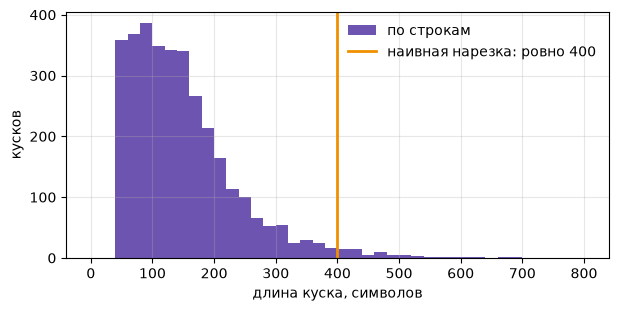

In [43]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([len(c["text"]) for c in line_chunks], bins=40, range=(0, 800), color=COLORS["violet"], alpha=0.85, label="по строкам")
ax.axvline(400, color=COLORS["amber"], lw=2, label="наивная нарезка: ровно 400")
ax.set_xlabel("длина куска, символов"); ax.set_ylabel("кусков"); ax.legend(frameon=False); ax.grid(alpha=0.3);

In [44]:
UNANSWERABLE = [
    "Who won the 2026 Stanley Cup in the National Hockey League?",
    "Which city was selected to host the 2032 Summer Olympic Games?",
    "Who was awarded the Nobel Prize in Chemistry in October 2026?",
    "What was the name of the near-Earth asteroid that impacted the Earth in September 2026?",
    "Who won the Best Actor award at the 99th Academy Awards held in 2027?",
    "Which political party won the majority in the 2026 Mexican general election?",
    "What was the official global release date of the PlayStation 6 console in 2026?",
    "Who was appointed as the new Chief Executive Officer of Microsoft in 2026?",
    "What was the magnitude of the earthquake that struck Istanbul, Turkey in August 2026?",
    "Which national team won the 2026 Rugby World Cup?"]

# Индекс в Milvus и качество поиска

Эмбеддинг текста не меняется, пока не меняются текст и модель, поэтому считать его дважды незачем. Кэш устроен просто: ключ это хэш текста, значение это вектор. Сначала в кэш загружается готовый файл из данных, потом всё, чего там нет, досчитывается через API пачками по 64 текста.

Вектор берём укороченный, 512 измерений вместо 1536: это «матрёшка», параметр `dimensions` в запросе. Ответ API втрое легче, память втрое меньше, качество почти то же. Пачка в 256 текстов на полной размерности это восемь мегабайт JSON, и на медленной сети такой запрос просто не доходит.

In [45]:
EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed("emb_cache.npz", keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

load_cache()

8302

In [46]:
def embed_cached(texts):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB)) #set нельзя т.к. нет порядка
    for i in range(0, len(missing), 64):
        batch = missing[i:i+64]
        for text, vector in zip(batch, embed_batch(batch)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)

    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
        


In [47]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

In [48]:
line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
save_cache()
line_vecs.shape, char_vecs.shape, q_vecs.shape

((3345, 512), (1331, 512), (44, 512))

In [49]:
probe = embed_cached(["Apple is a big techological company in USA", "Green apple is a tasty food from the my garden", "What was the weather in Tokyo yesterday?"])
save_cache()
(probe @ probe.T).round(2), ledger.table()

(array([[1.  , 0.27, 0.01],
        [0.27, 1.  , 0.02],
        [0.01, 0.02, 1.  ]], dtype=float32),
 Empty DataFrame
 Columns: [calls, prompt, completion, cost]
 Index: [])

In [ ]:
X (3 * 512) @ X.T (512 * 3) = A (3 * 3)

In [50]:
probe

array([[ 0.00411923, -0.04049051, -0.03000936, ..., -0.02994833,
         0.00115186, -0.03457102],
       [ 0.00601717, -0.02115356,  0.00516629, ..., -0.0727707 ,
        -0.03333289, -0.00468553],
       [ 0.00145331, -0.05599618, -0.08819018, ..., -0.06255705,
         0.01279368, -0.01237409]], shape=(3, 512), dtype=float32)

## Поиск на numpy и recall@k

Векторы нормализованы, значит косинусная близость это скалярное произведение, а близость вопроса ко всему корпусу это одно умножение матрицы на вектор. Для шести тысяч кусков этого хватает с запасом.

Качество поиска меряем отдельно от качества ответа. `recall@k` это доля вопросов, у которых верный кусок попал в первые k. Верным считаем кусок с той же страницы, в котором есть ответ и не меньше половины слов исходной строки: так наивная нарезка честно получает штраф за разорванные факты.


In [51]:
def search_numpy(query_vec, vectors, k=5):
    sims = vectors @ query_vec
    top = np.argsort(-sims)[:k]
    return[(int(i), float(sims[i])) for i in top]

In [52]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(chunks, vectors, ks=(1, 3, 5, 10, 20)):
    ranked = [[i for i, _ in search_numpy(q, vectors, max(ks))] for q in q_vecs]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

for i, score in search_numpy(q_vecs[0], line_vecs, 3):
    print(round(score, 3), "|", line_chunks[i]["page"], "|", line_chunks[i]["text"][:110])
tasks[0]["question"], tasks[0]["answer"]

0.74 | 2026 in India | 24 March – A special NIA court sentences Kashmiri separatist Asiya Andrabi to life imprisonment for her involv
0.557 | 2026 in India | Former Aam Aadmi Party (AAP) councillor Tahir Hussain is sentenced to life imprisonment for the murder of Inte
0.525 | 2026 in India | A special court in Madurai sentences all nine policemen accused in the 2020 Sathankulam custodial death case t


('What was the sentence given to Asiya Andrabi in March 2026 in India?',
 'life imprisonment')

,по строкам,по 400 символов
1,0.89,0.57
3,1.00,0.68
5,1.00,0.80
10,1.00,0.84
20,1.00,0.86


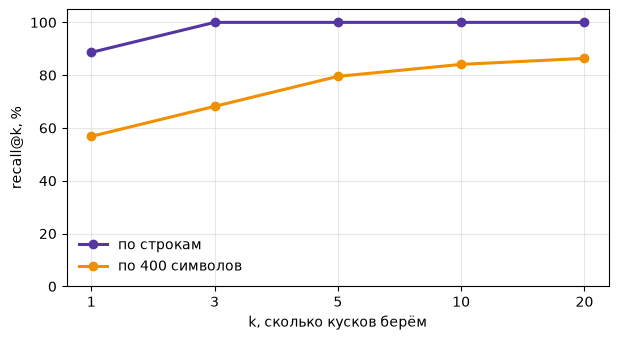

In [53]:
curves = {"по строкам": recall_curve(line_chunks, line_vecs), "по 400 символов": recall_curve(char_chunks, char_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

Возьмём для разбивки по строкам k = 5, то есть мы будем извлекать первые топ-5 чанков и передавать их в контекст модели для ответа на вопрос. Recall@k показывает долю релевантных chunks в первых топ-k для ответа на вопрос

## Milvus

Перебор на numpy честный и быстрый, но это только поиск. База добавляет то, что нужно продукту: хранение на диске, метаданные рядом с вектором, фильтры, добавление и удаление без пересборки, индекс для миллионов векторов и доступ по сети для нескольких сервисов сразу.

Milvus поднимаем так же, как его поднимают в жизни: контейнером. В папке лежит `docker-compose.yml`, в нём один сервис, сам Milvus в режиме standalone со встроенным etcd и локальным хранилищем.

```
docker compose up -d        поднять, база слушает localhost:19530
docker compose ps           статус должен стать healthy
docker compose logs -f      посмотреть, что происходит внутри
docker compose down         остановить, данные останутся в томе
docker compose down -v      остановить и стереть данные
```

В боевой установке etcd и объектное хранилище (MinIO или S3) живут отдельными сервисами, а сам Milvus раскладывается на несколько узлов. Код клиента от этого не меняется: меняется только адрес в `MILVUS_URI`.

Рядом с вектором храним всё, что понадобится показать человеку и подложить модели: текст куска, страницу, раздел, ссылку. Поля, которых нет в схеме, Milvus складывает как динамические, и по ним можно фильтровать. После вставки зовём `flush`: он запечатывает сегмент, по нему строится индекс, а `row_count` в статистике становится точным.




In [54]:
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
if os.getenv("MILVUS_DB"):
    if os.environ["MILVUS_DB"] not in client.list_databases():
        client.create_database(os.environ["MILVUS_DB"])
    client.use_database(os.environ["MILVUS_DB"])
client.get_server_version(), client.list_collections()

('2.6.24', ['lines'])

In [55]:
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection(name)
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    rows = [{"id": i, "vector": v.tolist(), **c} for i, (c, v) in enumerate(zip(chunks, vectors))]
    for i in range(0, len(rows), 1000):
        client.insert(name, rows[i:i+1000])

    client.flush(name)
    return client.get_collection_stats(name)

In [56]:
def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]

    return [{**h['entity'], "id": h["id"], "score": round(h["distance"], 4)} for h in hits ]

In [57]:
index_to_milvus("lines", line_chunks, line_vecs), client.describe_index("lines", "vector")

({'row_count': 3345},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 3345,
  'indexed_rows': 0,
  'pending_index_rows': 3345,
  'state': 'InProgress'})

In [58]:
pd.DataFrame(search_milvus("lines", tasks[0]["question"], 3))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.7396,2026 in India,March,24 March – A special NIA court sentences Kashm...
1,0.5572,2026 in India,July,Former Aam Aadmi Party (AAP) councillor Tahir ...
2,0.5254,2026 in India,April,A special court in Madurai sentences all nine ...


In [59]:
page = tasks[0].get("page")
page

'2026 in India'

In [60]:
pages = sorted({c.get("page") for c in line_chunks if c.get("page")})
len(pages)

14

In [61]:
pages

['2026',
 '2026 in Australia',
 '2026 in Brazil',
 '2026 in Canada',
 '2026 in China',
 '2026 in France',
 '2026 in Germany',
 '2026 in India',
 '2026 in Japan',
 '2026 in Russia',
 '2026 in South Korea',
 '2026 in science',
 '2026 in the United Kingdom',
 '2026 in the United States']

In [62]:
pd.DataFrame(search_milvus("lines", tasks[0]["question"], 3, flt=f'page == "{pages[-3]}"'))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.3187,2026 in science,January,24 January – AES Andes abandons the INNA proje...
1,0.2862,2026 in science,April,6 April – In a landmark achievement for India'...
2,0.2788,2026 in science,May,31 May – A Phase 3 trial published in the New ...


In [63]:
import json
import re

FIELD_RE = re.compile(r"^[A-Za-z_][A-Za-z0-9_]*$")


def safe_eq(field: str, value) -> str:
    """
    Делает Milvus-фильтр вида: field == "value"
    Безопасно экранирует значение через json.dumps.
    """
    if not FIELD_RE.match(field):
        raise ValueError(f"Некорректное имя поля: {field!r}")

    value = str(value).strip()

    if not value:
        return ""

    return f'{field} == {json.dumps(value, ensure_ascii=False)}'


def safe_page_filter(page) -> str:
    """
    Фильтр по page. Если page пустой — возвращает пустую строку, то есть без фильтра.
    """
    if page is None:
        return ""

    page = str(page).strip()

    if not page:
        return ""

    return safe_eq("page", page)


def combine_filters(*parts: str) -> str:
    """
    Собирает фильтры через AND. Пустые части игнорируются.
    """
    return " and ".join(p for p in parts if p)

In [64]:
from_numpy = [[i for i, _ in search_numpy(q, line_vecs, 5)] for q in q_vecs]
from_milvus = [[h["id"] for h in hits] for hits in client.search("lines", data=q_vecs.tolist(), limit=5)]
overlap = float(np.mean([len(set(a) & set(b)) / 5 for a, b in zip(from_numpy, from_milvus)]))
round(overlap, 3), sum(a == b for a, b in zip(from_numpy, from_milvus)), len(q_vecs)

(0.941, 30, 44)

In [65]:
pd.DataFrame(search_milvus("lines", "Eurovision", 5, 'page == "2026 in France"'))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.4622,2026 in France,May,16 May – France's Monroe finishes 11th at Euro...
1,0.2809,2026 in France,Deaths,"28 July – Kavinsky, 50, musician (""Nightcall"",..."
2,0.2620,2026 in France,April,23 April – France and the United Kingdom sign ...
3,0.2604,2026 in France,May,20 May – France begins refusing temporary resi...
4,0.2596,2026 in France,Predicted and scheduled events,27 September – 2026 French Senate election


In [66]:
def per_query_ms(fn, n=100):
    started = time.perf_counter()
    fn()
    return (time.perf_counter() - started) * 1000 / n

{'numpy, перебор': 0.1,
 'Milvus, запрос на вызов': 2.0,
 'Milvus, сто запросов пачкой': 0.62}

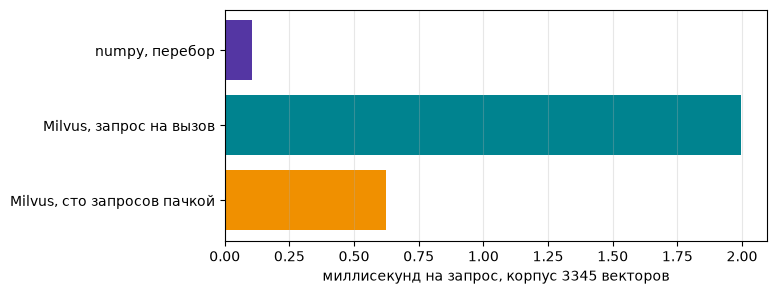

In [67]:
queries = q_vecs[:100]
speed = {"numpy, перебор": per_query_ms(lambda: [search_numpy(q, line_vecs, 5) for q in queries]),
         "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("lines", data=[q.tolist()], limit=5) for q in queries]),
         "Milvus, сто запросов пачкой": per_query_ms(lambda: client.search("lines", data=queries.tolist(), limit=5))}
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(speed), list(speed.values()), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.invert_yaxis(); ax.set_xlabel(f"миллисекунд на запрос, корпус {len(line_vecs)} векторов"); ax.grid(alpha=0.3, axis="x")
{name: round(ms, 2) for name, ms in speed.items()}

In [68]:
def inflate(vectors, n, noise=0.35, seed=0):
    rng = np.random.default_rng(seed)
    extra = vectors[rng.integers(0, len(vectors), n - len(vectors))]
    extra = extra + noise * rng.standard_normal(extra.shape, dtype=np.float32) / np.sqrt(vectors.shape[1])
    return np.vstack([vectors, extra / np.linalg.norm(extra, axis=1, keepdims=True)])

def wait_index(name, seconds=180):
    for _ in range(seconds):
        info = client.describe_index(name, "vector")
        if info.get("state") == "Finished" and info.get("pending_index_rows", 0) == 0:
            return True
        time.sleep(1)
    return False

,"numpy, перебор","Milvus, запрос на вызов","Milvus, пачкой"
векторов,,,
3345,0.30,6.02,0.80
50000,4.79,4.02,0.78
200000,20.22,8.67,1.89


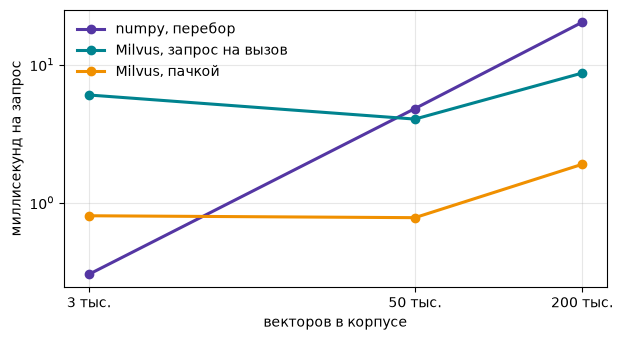

In [69]:
scale_rows = []
for n in (len(line_vecs), 50_000, 200_000):
    big = inflate(line_vecs, n)
    if client.has_collection("scale"):
        client.drop_collection("scale")
    client.create_collection("scale", dimension=big.shape[1], metric_type="COSINE")
    for i in range(0, n, 5000):
        client.insert("scale", [{"id": i + j, "vector": v} for j, v in enumerate(big[i:i + 5000].tolist())])
    client.flush("scale")
    wait_index("scale")
    client.search("scale", data=[q_vecs[0].tolist()], limit=5)
    probe = q_vecs[:50]
    scale_rows.append({"векторов": n,
                       "numpy, перебор": per_query_ms(lambda: [search_numpy(q, big, 5) for q in probe], 50),
                       "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("scale", data=[q.tolist()], limit=5) for q in probe], 50),
                       "Milvus, пачкой": per_query_ms(lambda: client.search("scale", data=probe.tolist(), limit=5), 50)})
client.drop_collection("scale")
scale = pd.DataFrame(scale_rows).set_index("векторов")
ax = scale.plot(figsize=(7, 3.6), marker="o", lw=2.2, logx=True, logy=True, color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.set_xticks(list(scale.index)); ax.set_xticklabels([f"{n / 1000:.0f} тыс." for n in scale.index]); ax.minorticks_off()
ax.set_ylabel("миллисекунд на запрос"); ax.set_xlabel("векторов в корпусе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
ax.figure.savefig("img/scale.png", dpi=150, bbox_inches="tight")
scale.round(2)

## RAG система

In [70]:
RAG_SYSTEM = ("Answer the question using only the numbered sources. Cite the source number like [2]. "
              "If the sources do not contain the answer, reply exactly NOT_FOUND. The last line must be FINAL: <short answer>.")
PLAIN_SYSTEM = "Answer the question. If you do not know, reply NOT_FOUND. The last line must be FINAL: <short answer>."

In [71]:
def rag_answer(question, model, k=5, name="lines"):
    hits = search_milvus(name, question, k)
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits))
    before = ledger.mine
    msg = chat([{"role": "system", "content": RAG_SYSTEM},
                {"role": "user", "content": f"Sources\n{sources}\n\nQuestion:{question}"}], model, tag="rag")
    return {"answer": msg.get("content") or "", "hits": hits, "cost": ledger.mine - before}

In [72]:
def plain_answer(question, model):
    before = ledger.mine
    msg = chat([{"role": "system", "content": PLAIN_SYSTEM}, {"role": "user", "content": question}], model, tag="plain")
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before}

In [73]:
def normalize(text):
    text = re.sub(r"[^\w\s]", " ", str(text).lower().replace(",", ""))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def parse_date(text):
    """Функция извлекает дату из текста 
    и приводит её к единому формату, чтобы можно было сравнивать.
    Например, 15 March и March 15 будут одинаковыми"""
    
    months = r"(January|February|March|April|May|June|July|August|September|October|November|December)"
    m = re.search(rf"(\d{{1,2}})\s+{months}(?:\s+\d{{4}})?", str(text), re.I)
    if m: return f"{m.group(1)} {m.group(2).lower()}"
    m = re.search(rf"{months}\s+(\d{{1,2}})(?:,?\s+\d{{4}})?", str(text), re.I)
    if m: return f"{m.group(2)} {m.group(1).lower()}"
    return None

In [74]:
def is_correct(task, answer):
    if task.get("source") == "gsm8k":
        nums = re.findall(r"-?\d+(?:\.\d+)?", str(answer).replace(",", ""))
        return bool(nums) and abs(float(nums[-1]) - float(task["answer"])) < 1e-6
    
    if normalize(task["answer"]) in normalize(answer): return True
    
    # Проверка дат ("15 March" == "March 15")
    gold_date = parse_date(task["answer"])
    ans_date = parse_date(answer)
    if gold_date and ans_date: return gold_date == ans_date
    return False

def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def evaluate(fn, sample, config, model, workers=8):
    def one(task):
        try:
            out = fn(task["question"], model)
        except Exception as e:
            out = {"answer": f"ошибка: {e}", "hits": [], "cost": 0.0}
        return {"config": config, "model": model.split("/")[-1], "id": task["id"], "correct": is_correct(task, out["answer"]),
                "found": any(is_gold(h, task) for h in out["hits"]), "refused": "NOT_FOUND" in out["answer"],
                "cost": out["cost"], "answer": final_answer(out["answer"])[:60], "gold": task["answer"]}
    with ThreadPoolExecutor(workers) as pool:
        return pd.DataFrame(list(pool.map(one, sample)))

def report(results):
    g = results.groupby(["config", "model"], sort=False)
    table = g.agg(n=("correct", "size"), accuracy=("correct", "mean"), cost_per_task=("cost", "mean")).reset_index()
    table["cost_per_correct"] = table["cost_per_task"] / table["accuracy"].replace(0, float("nan"))
    return table.round(5)

def money_chart(table, path, baseline=None):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    if baseline:
        ax.axhline(baseline[1] * 100, color=COLORS["grey"], ls="--", lw=1.2)
        ax.annotate(baseline[0], (0.01, baseline[1] * 100 + 1.5), xycoords=("axes fraction", "data"), fontsize=8, color=COLORS["grey"])
    for _, r in table.iterrows():
        color = COLORS["amber"] if "sonnet" in r["model"] else COLORS["teal"] if "haiku" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100), fontsize=8, xytext=(7, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %"); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig



In [75]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        result = spec["fn"](**spec["args"].model_validate_json(call["function"]["arguments"]).model_dump())
    except Exception as e:
        result = f"ошибка инструмента {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:3000]}

AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")

def agent(question, model, max_steps=6):
    messages, seen, before = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set(), ledger.mine
    schemas = [t["schema"] for t in TOOLS.values()]
    for step in range(max_steps):
        msg = chat(messages, model, tools=schemas, tag="agent")
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        keys = {(c["function"]["name"], c["function"]["arguments"]) for c in calls}
        if not calls or keys & seen or step == max_steps - 1:
            break
        seen |= keys
        messages += [run_tool(c) for c in calls]
    if calls:
        messages += [{"role": "tool", "tool_call_id": c["id"], "content": "call rejected: answer from what you already have"} for c in calls]
        msg = chat(messages, model, tag="agent")
    searches = sum(m.get("role") == "tool" for m in messages if isinstance(m, dict))
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before, "searches": searches}

class KBArgs(BaseModel):
    query: str = Field(description="short search query in English: names, dates, key terms of the event")
    page: str = Field(default="", description="optional exact page title to search within, for example '2026 in Japan'; empty means all pages")

In [76]:
def knowledge_base(query: str, page: str = "") -> str:
    hits = search_milvus("lines", query, 5, f'page == "{page}"' if page else "")
    if not hits:
        return "nothing found"
    return "\n".join(f"[{h['page']} / {h['section']}] {h['text']}" for h in hits)

In [77]:
def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

In [78]:
WIKI_EN = "https://en.wikipedia.org/w/api.php"
WIKI_RU = "https://ru.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "search-agents (https://yandex.ru)"}

def wiki(params, url=WIKI_EN, attempts=3):
    for attempt in range(attempts):
        try:
            r = requests.get(url, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=20)
            if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
                return r.json()["query"]
        except requests.RequestException:
            pass
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Wiki {url} недоступна")

In [79]:
def web_search(query: str) -> str:
    try:
        hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1})["search"]

        if not hits:
            return "No data"
        pages = wiki({"action":"query", "prop": "extracts", "explainttext": 1, "exinro": 1, "titles": hits[0]["title"]})["pages"]
        text = " ".join(next(iter(pages.values())).get("extract", "").split())
        return f"[{hits[0]["title"]}] {text[:5000]}"
    except Exception as e:
            return f"en wiki error: {e}"

In [80]:
def web_search_ru(query: str) -> str:
    """Второй источник: Русская Википедия."""
    try:
        hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1}, url=WIKI_RU)["search"]
        if not hits: return "nothing found in ru wiki"
        pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]}, url=WIKI_RU)["pages"]
        text = " ".join(next(iter(pages.values())).get("extract", "").split())[:1500]
        return f"[{hits[0]['title']}] {text}"
    except Exception as e:
        return f"ru wiki error: {e}"

In [81]:
import ast
import operator


OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate_calc(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate_calc(node.left), evaluate_calc(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate_calc(node.operand))
    raise ValueError("допустимы только числа и арифметика")


def calculator(expr: str) -> str:
    try:
        val = evaluate_calc(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"ошибка вычисления: {e}"

In [82]:
import subprocess


def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "Код превысил 5 сек"
    out = (r.stdout + r.stderr).strip()
    return out[:5000] if out else "Код исполнился но результат пустой"


In [83]:
def page_find(title, keywords):
    """Строки полного текста статьи, где встречается хотя бы половина ключевых слов."""
    pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "titles": title, "redirects": 1})["pages"]
    text = next(iter(pages.values())).get("extract", "")
    if not text:
        return "no such page"
    words = [w for w in re.findall(r"\w+", keywords.lower()) if len(w) > 2]
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    hits = [l for l in lines if sum(w in l.lower() for w in words) >= max(1, (len(words) + 1) // 2)]
    return "\n".join(h[:400] for h in hits[:6]) or "keywords not found on the page"

In [84]:
class SearchArgs(BaseModel): query: str = Field(description="короткий поисковый запрос на английском")
class PageFindArgs(BaseModel): 
    title: str = Field(description="точное название статьи, например '2026 in Japan'")
    keywords: str = Field(description="два-пять ключевых слов из вопроса")
class RuSearchArgs(BaseModel): query: str = Field(description="поисковый запрос на русском")
class CalcArgs(BaseModel): expr: str = Field(description="арифметическое выражение")
class ExecArgs(BaseModel): code: str = Field(description="код на Python")

In [85]:
register(web_search, SearchArgs, "Ищет статью в англоязычной Википедии и возвращает её вступление")
register(page_find, PageFindArgs, "Ищет строки с ключевыми словами внутри полной статьи Википедии. Используй для длинных обзорных страниц.")
register(web_search_ru, RuSearchArgs, "Ищет статью в русскоязычной Википедии. Используй для вопросов про Россию или на русском.")
register(calculator, CalcArgs, "Считает арифметическое выражение")
register(python_exec, ExecArgs, "Выполняет код на Python и возвращает print")

In [86]:
register(knowledge_base, KBArgs, "Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section")
out = agent(tasks[3]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[3]["answer"], "| обращений к базе:", out["searches"], "| цена, центов:", round(out["cost"] * 100, 4))

The attack investigated by Counter Terrorism Policing on May 10, 2026, occurred at the former East London Central Synagogue in Whitechapel. 

FINAL: East London Central Synagogue, Whitechapel | эталон: East London Central Synagogue | обращений к базе: 1 | цена, центов: 0.0223


In [96]:
def test_knowledge_base_returns_sources():
    out = knowledge_base(tasks[0]["question"])

    assert isinstance(out, str)
    assert "2026" in out or "No matching sources" in out


def test_knowledge_base_handles_empty_query():
    out = knowledge_base("dalsjdal")

    assert isinstance(out, str)
    assert "nothing found"


def test_knowledge_base_page_filter():
    pages = sorted({c.get("page") for c in line_chunks if c.get("page")})

    if not pages:
        print("Нет page в line_chunks, пропускаю тест фильтра.")
        return

    some_page = pages[0]

    out = knowledge_base(tasks[0]["question"], page=some_page)

    assert isinstance(out, str)
    assert "Knowledge base search failed" not in out

In [97]:
test_knowledge_base_returns_sources()
test_knowledge_base_handles_empty_query()
test_knowledge_base_page_filter()

In [125]:
baseline_results = pd.read_csv(Path("summary_table.csv"))
baseline_results = baseline_results.loc[baseline_results["config"] == 'дешёвая, только поиск', ["config", "model", "n", "accuracy", 
                                                                             "cost_per_task", "cost_per_correct"]]

In [126]:
baseline_results

,config,model,n,accuracy,cost_per_task,cost_per_correct
3,"дешёвая, только поиск",gpt-4o-mini,40,0.17,0.00142,0.0081


In [127]:
baseline_results.iloc[[0]]

,config,model,n,accuracy,cost_per_task,cost_per_correct
3,"дешёвая, только поиск",gpt-4o-mini,40,0.17,0.00142,0.0081


In [103]:
sample = tasks[:40]

In [102]:
out = rag_answer(tasks[0]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

Asiya Andrabi was sentenced to life imprisonment for her involvement in terrorist activities in Kashmir in March 2026 [1]. 

FINAL: life imprisonment. | эталон: life imprisonment | цена, центов: 0.0061


In [ ]:
results = pd.concat([
    evaluate(plain_answer, sample, "сильная модель, без инструментов", MODELS["strong"]),
    evaluate(rag_answer, sample, "дешёвая модель, RAG всегда", MODELS["cheap"]),
    evaluate(agent, sample, "дешёвая модель, агент с knowledge_base", MODELS["cheap"]),
    evaluate(rag_answer, sample, "средняя модель, RAG всегда", MODELS["mid"]),
], ignore_index=True)


In [137]:
results.to_csv(Path("results_rag_and_agent_iteration.csv"), index=False)

In [138]:
pd_list = [report(results.loc[results["config"] == "сильная модель, без инструментов"]),
           baseline_results, 
           report(results.loc[results["config"] != "сильная модель, без инструментов"])]

In [139]:
pd.concat(pd_list, ignore_index=True).to_csv(Path("summary_results_rag_and_agent.csv"), index=False)

In [140]:
final_table = pd.concat(pd_list, ignore_index=True)

In [141]:
final_table

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,"сильная модель, без инструментов",claude-sonnet-4.6,40,0.025,0.00110,0.04407
1,"дешёвая, только поиск",gpt-4o-mini,40,0.170,0.00142,0.00810
2,"дешёвая модель, RAG всегда",gpt-4o-mini,40,0.925,0.00006,0.00007
3,"дешёвая модель, агент с knowledge_base",gpt-4o-mini,40,0.925,0.00023,0.00024
4,"средняя модель, RAG всегда",claude-haiku-4.5,40,0.975,0.00069,0.00071


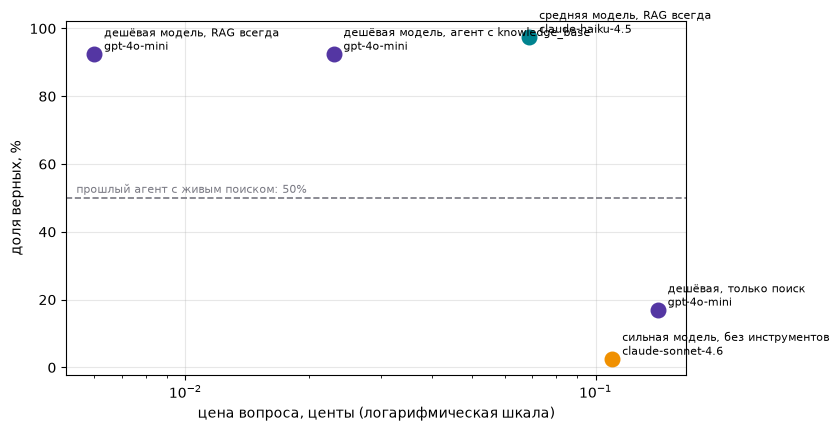

In [144]:
last_week = float(np.mean([t["agent_ok"] for t in sample]))
money_chart(final_table, "img/money_all.png", baseline=(f" прошлый агент с живым поиском: {last_week:.0%}", last_week));

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,k=1,gpt-4o-mini,40,0.875,0.00003,0.00004
1,k=3,gpt-4o-mini,40,0.900,0.00005,0.00005
2,k=5,gpt-4o-mini,40,0.925,0.00006,0.00007
3,k=10,gpt-4o-mini,40,0.925,0.00010,0.00011


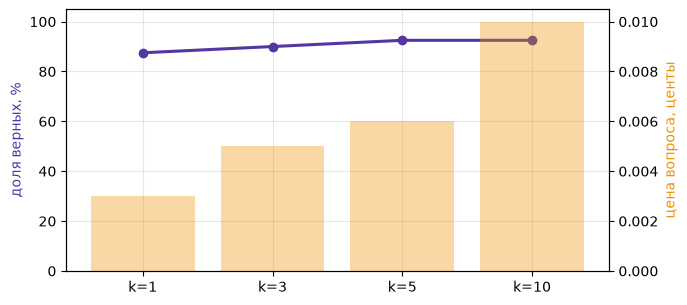

In [146]:
sweep = pd.concat([evaluate(lambda q, m, k=k: rag_answer(q, m, k), sample, f"k={k}", MODELS["cheap"]) for k in (1, 3, 5, 10)], ignore_index=True)
sweep_table = report(sweep)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sweep_table["config"], sweep_table["accuracy"] * 100, marker="o", lw=2.2, color=COLORS["violet"]); ax.set_ylabel("доля верных, %", color=COLORS["violet"])
ax2 = ax.twinx(); ax2.bar(sweep_table["config"], sweep_table["cost_per_task"] * 100, alpha=0.35, color=COLORS["amber"]); ax2.set_ylabel("цена вопроса, центы", color=COLORS["amber"])
ax.set_ylim(0, 105); ax.grid(alpha=0.3)
sweep_table

# Отказы

In [145]:
refusals = [rag_answer(q, MODELS["cheap"]) for q in UNANSWERABLE]
sum("NOT_FOUND" in r["answer"] for r in refusals), [final_answer(r["answer"])[:40] for r in refusals if "NOT_FOUND" not in r["answer"]]

(10, [])

In [165]:
refusals

[{'answer': 'NOT_FOUND.  \nFINAL: NOT_FOUND.',
  'hits': [{'text': 'In ice hockey, the Carolina Hurricanes beat the Montreal Canadiens in five games during the Eastern Conference Finals to advance to the 2026 Stanley Cup finals, making it their first appearance in the Stanley Cup since 2006.',
    'page': '2026 in the United States',
    'section': 'May',
    'url': 'https://en.wikipedia.org/wiki/2026_in_the_United_States',
    'id': 3038,
    'score': 0.6343},
   {'text': 'In ice hockey, the Minnesota Wild defeat the Dallas Stars in six games in the 2026 Stanley Cup playoffs following a 5–2 victory to win a playoff series for the first time since 2015, ending an 11-year drought.',
    'page': '2026 in the United States',
    'section': 'April',
    'url': 'https://en.wikipedia.org/wiki/2026_in_the_United_States',
    'id': 2970,
    'score': 0.6298},
   {'text': 'April 4 – 2025–26 NHL season: In ice hockey, the Buffalo Sabres clinched the Stanley Cup playoffs for the first time since 

# Разбор провалов

У RAG две половины, и ломаются они по-разному. Поиск мог не найти нужный кусок. А мог найти, но модель ответила неверно или отказалась. Чинятся эти случаи в разных местах, поэтому первым делом раскладываем ошибки на две кучки.

Дальше три приёма. Гибрид: вектор ловит смысл, поиск по словам ловит точные имена и числа, слияние рангов RRF берёт лучшее от обоих. Проверим его на обеих нарезках: и там, где вектору тяжело, и там, где он уже хорош. Отказ: десять вопросов, ответа на которые в корпусе нет, и подсчёт, сколько раз система честно сказала `NOT_FOUND`. Порог близости: у неотвечаемых вопросов лучший кусок заметно дальше, и это дешёвый сигнал для отказа ещё до вызова модели.

In [147]:
def diagnose(results):
    wrong = results[~results["correct"] & results["config"].str.contains("RAG")]
    return wrong.groupby("model").agg(не_нашли=("found", lambda s: int((~s).sum())), нашли_но_ответ_неверный=("found", "sum"))

diagnose(results)

,не_нашли,нашли_но_ответ_неверный
model,,
claude-haiku-4.5,0,1
gpt-4o-mini,0,3


In [154]:
results[~results["correct"] & (results["config"] == "средняя модель, RAG всегда")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
144,claude-haiku-4.5,Decision 2026-911,The Constitutional Council ruled that the soci...,True


In [155]:
results[~results["correct"] & (results["config"] == "дешёвая модель, RAG всегда")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
49,gpt-4o-mini,Sansad Chalo March,2026 Delhi Jantar Mantar protests.,True
64,gpt-4o-mini,Decision 2026-911,The social media ban for minors under 15 years...,True
77,gpt-4o-mini,Jake Lang,NOT_FOUND,True


In [167]:
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
top_unanswerable

[0.6343, 0.5987, 0.5828, 0.4977, 0.5902, 0.5684, 0.4615, 0.5761, 0.514, 0.63]

In [168]:
refusals[0]

{'answer': 'NOT_FOUND.  \nFINAL: NOT_FOUND.',
 'hits': [{'text': 'In ice hockey, the Carolina Hurricanes beat the Montreal Canadiens in five games during the Eastern Conference Finals to advance to the 2026 Stanley Cup finals, making it their first appearance in the Stanley Cup since 2006.',
   'page': '2026 in the United States',
   'section': 'May',
   'url': 'https://en.wikipedia.org/wiki/2026_in_the_United_States',
   'id': 3038,
   'score': 0.6343},
  {'text': 'In ice hockey, the Minnesota Wild defeat the Dallas Stars in six games in the 2026 Stanley Cup playoffs following a 5–2 victory to win a playoff series for the first time since 2015, ending an 11-year drought.',
   'page': '2026 in the United States',
   'section': 'April',
   'url': 'https://en.wikipedia.org/wiki/2026_in_the_United_States',
   'id': 2970,
   'score': 0.6298},
  {'text': 'April 4 – 2025–26 NHL season: In ice hockey, the Buffalo Sabres clinched the Stanley Cup playoffs for the first time since the 2010–11 se

(0.743, 0.579)

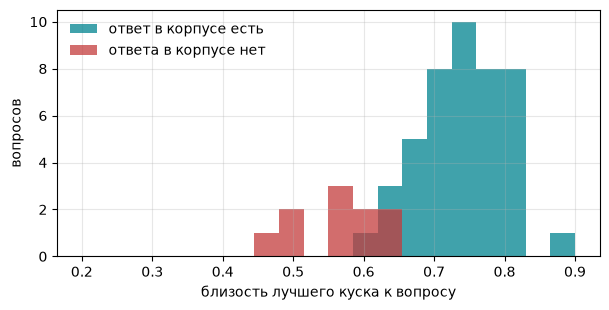

In [161]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(top_answerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["teal"], label="ответ в корпусе есть")
ax.hist(top_unanswerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["red"], label="ответа в корпусе нет")
ax.set_xlabel("близость лучшего куска к вопросу"); ax.set_ylabel("вопросов"); ax.legend(frameon=False); ax.grid(alpha=0.3)
round(float(np.median(top_answerable)), 3), round(float(np.median(top_unanswerable)), 3)

In [156]:
results[results["correct"] & (results["config"] == "дешёвая модель, RAG всегда")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
40,gpt-4o-mini,life imprisonment,life imprisonment.,True
41,gpt-4o-mini,College World Series,College World Series.,True
42,gpt-4o-mini,26 January,26 January.,True
43,gpt-4o-mini,East London Central Synagogue,East London Central Synagogue in Whitechapel.,True
44,gpt-4o-mini,an alleged bomb threat,bomb threat investigation.,True
45,gpt-4o-mini,Primeiro Comando da Capital,Primeiro Comando da Capital and Comando Vermelho.,True
46,gpt-4o-mini,six people,6,True
47,gpt-4o-mini,Eighteen people,18,True
48,gpt-4o-mini,Elon Musk,Elon Musk.,True
50,gpt-4o-mini,30 June,30 June 2026.,True


In [159]:
results[results["correct"] & (results["config"] == "сильная модель, без инструментов")][["model", "gold", "answer", "found"]]


,model,gold,answer,found
22,claude-sonnet-4.6,Noida International Airport,Donyi Polo Airport (among several airports ina...,False


In [150]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

In [151]:
def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)

    return sorted(scores, key=scores.get, reverse=True)[:k]

,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.57,0.80
1,по 400 символов,только слова,0.70,0.84
2,по 400 символов,гибрид RRF,0.68,0.82
3,по строкам,только вектор,0.89,1.00
4,по строкам,только слова,0.93,1.00
5,по строкам,гибрид RRF,0.93,1.00


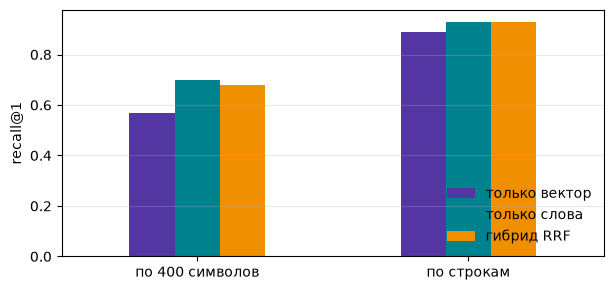

In [152]:
def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@1")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@1"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.57,0.80
1,по 400 символов,только слова,0.70,0.84
2,по 400 символов,гибрид RRF,0.68,0.82
3,по строкам,только вектор,0.89,1.00
4,по строкам,только слова,0.93,1.00
5,по строкам,гибрид RRF,0.93,1.00


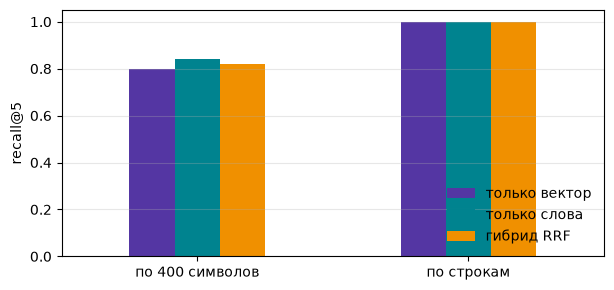

In [160]:
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@5")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@5"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

## Память

У модели памяти нет: помнит ваш код, который кладёт нужное в контекст.

Эпизодическая: журнал всех реплик в файле, в контекст он не идёт. Семантическая: короткие факты о пользователе, которые дешёвая модель извлекает из диалога отдельным вызовом. Она возвращает обновлённый список целиком, поэтому «переехал», «передумал», «больше не интересуюсь» заменяют старый факт, а не ложатся рядом с ним.

Факты лежат там же, где знания: в Milvus, отдельной коллекцией. К вопросу достаём не все факты, а три ближайших. В контекст идут системный промпт, эти факты, найденные куски корпуса и окно последних реплик. Вся остальная история остаётся в журнале.

Память помогает и поиску. «Что нового в моих темах?» без фактов не ищется никак, а факты, приклеенные к каждому запросу, портят конкретные вопросы: к вопросу про футбол подмешивается хоккей. Поэтому ищем дважды, по самому вопросу и по вопросу с фактами, и сливаем два списка через `rrf`. Искать имеет смысл только на вопросы: на «привет, я аналитик» база вернёт пять случайных строк, и модель послушно начнёт их пересказывать. Пока это грубая проверка на вопросительный знак

In [172]:
FACTS_SYSTEM = ("Ты ведёшь память ассистента о пользователе. Верни один JSON-объект вида {\"facts\": [\"...\"]}: полный обновлённый список "
                "коротких фактов о пользователе. Добавь новые устойчивые факты: имя, город, работа, интересы, пожелания к ответам. "
                "Если новый факт отменяет старый, замени старый. Разовые вопросы и мелочи не записывай.")
ASSISTANT_SYSTEM = ("Ты помощник, который отвечает на вопросы о событиях 2026 года по базе знаний. Отвечай на языке пользователя, "
                    "опирайся на источники и на то, что знаешь о пользователе. Источники подобраны автоматически и могут быть не по теме: "
                    "используй только те, что относятся к вопросу. Если в источниках ответа нет, так и скажи.")
JOURNAL, FACTS_FILE = Path("episodes.jsonl"), Path("facts.json")

class Facts(BaseModel):
    facts: list[str] = Field(description="короткие факты о пользователе")

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    cleaned = re.sub(r'(\\["\\/bfnrtu])|\\', lambda e: e.group(1) or "\\\\", m.group(0) if m else "{}")
    return json.loads(cleaned, strict=False)

def known_facts():
    return json.loads(FACTS_FILE.read_text(encoding="utf-8")) if FACTS_FILE.exists() else []

def store_facts(facts):
    FACTS_FILE.write_text(json.dumps(facts, ensure_ascii=False, indent=1), encoding="utf-8")
    if facts:
        index_to_milvus("facts", [{"page": "memory", "section": "", "url": "", "text": f} for f in facts], embed_cached(facts))

def remember_episode(session, role, text):
    with JOURNAL.open("a", encoding="utf-8") as f:
        f.write(json.dumps({"session": session, "time": time.strftime("%Y-%m-%d %H:%M:%S"), "role": role, "text": text}, ensure_ascii=False) + "\n")

for path in (JOURNAL, FACTS_FILE):
    path.unlink(missing_ok=True)
if client.has_collection("facts"):
    client.drop_collection("facts")

In [173]:
def extract_facts(dialog, known):
    prompt = f"Известные факты: {json.dumps(known, ensure_ascii=False)}\n\nДиалог:\n{dialog}"
    msg = chat([{"role": "system", "content": FACTS_SYSTEM}, {"role": "user", "content": prompt}], MODELS['cheap'], tag="memory")
    return Facts.model_validate(json_from(msg["content"])).facts

In [174]:
def recall_facts(question, k=3):
    if not client.has_collection("facts"):
        return []
    return [h["text"] for h in search_milvus("facts", question, k)]

In [175]:
def search_with_memory(user_text, facts, k=5):
    plain = search_milvus("lines", user_text, k)
    personal = search_milvus("lines", user_text + " " + " ".join(facts), k) if facts else []
    by_id = {h["id"]: h for h in plain + personal}
    return [by_id[i] for i in rrf([[h["id"] for h in plain], [h["id"] for h in personal]], k)]

def talk(session, history, user_text, mode="память"):
    remember_episode(session, "user", user_text)
    facts = recall_facts(user_text) if mode == "память" else []
    hits = search_with_memory(user_text, facts) if "?" in user_text else []
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits)) or "нет"
    system = ASSISTANT_SYSTEM + ("\nЧто известно о пользователе: " + "; ".join(facts) if facts else "")
    window = history[-4:] if mode == "память" else history
    msg = chat([{"role": "system", "content": system}] + window + [{"role": "user", "content": f"Источники:\n{sources}\n\n{user_text}"}],
               MODELS["cheap"], tag=f"dialog: {mode}")
    answer = msg.get("content") or ""
    history += [{"role": "user", "content": user_text if mode == "память" else f"Источники:\n{sources}\n\n{user_text}"}, {"role": "assistant", "content": answer}]
    remember_episode(session, "assistant", answer)
    return answer

def end_session(history):
    dialog = "\n".join(f"{m['role']}: {m['content'][:400]}" for m in history)
    store_facts(extract_facts(dialog, known_facts()))
    return known_facts()

In [ ]:
first = []
print(talk("s1", first, "Привет! Я Никита, мл инженер из Санкт-Петербурга. Слежу за баскетболом, хоккем, ИТ, ИИ, отвечай коротко."))
print(talk("s1", first, "Что было в хоккее весной-летом 26 года?"))
end_session(first)

Привет, Никита! К сожалению, у меня нет информации о событиях 2026 года. Если у тебя есть другие вопросы или темы, которые тебя интересуют, дай знать!
Весной и летом 2026 года в хоккее произошло несколько значимых событий. В частности, в плейоф НХЛ команда Minnesota Wild одержала победу над Dallas Stars в шести играх, выиграв серию плейоф впервые с 2015 года, что положило конец 11-летнему ожиданию успеха в плейофах. Если тебе нужна более подробная информация или другие события, дай знать!


['Имя: Никита',
 'Город: Санкт-Петербург',
 'Работа: мл инженер',
 'Интересы: баскетбол, хоккей, ИТ, ИИ',
 'Пожелания к ответам: отвечай коротко']

In [197]:
first

[{'role': 'user',
  'content': 'Привет! Я Никита, мл инженер из Санкт-Петербурга. Слежу за баскетболом, хоккем, ИТ, ИИ, отвечай коротко.'},
 {'role': 'assistant',
  'content': 'Привет, Никита! К сожалению, у меня нет информации о событиях 2026 года. Если у тебя есть другие вопросы или темы, которые тебя интересуют, дай знать!'},
 {'role': 'user', 'content': 'Что было в хоккее весной-летом 26 года?'},
 {'role': 'assistant',
  'content': 'Весной и летом 2026 года в хоккее произошло несколько значимых событий. В частности, в плейоф НХЛ команда Minnesota Wild одержала победу над Dallas Stars в шести играх, выиграв серию плейоф впервые с 2015 года, что положило конец 11-летнему ожиданию успеха в плейофах. Если тебе нужна более подробная информация или другие события, дай знать!'}]

In [198]:
second = []
print(talk("s2", second, "Что интересного случилось в моих темах за лето?"))
print(talk("s2", second, "Хоккей мне надоел, теперь стал следить за американским футболом. И я переехала в Москву."))
print(talk("s2", second, "Кто выиграл национальный чемпионат NСAA по американскому футболу в 2026?"))
end_session(second)

К сожалению, в источниках нет информации о событиях в баскетболе, хоккее или ИТ за лето 2026 года. Однако, в области науки и технологий в 2026 году произошло много интересного, включая достижения в области искусственного интеллекта и космических исследований, такие как миссия NASA Artemis II. Если вас интересуют конкретные события в этих областях, дайте знать!
Понял, Никита! К сожалению, у меня нет информации о событиях в американском футболе за лето 2026 года. Если у вас есть какие-то конкретные вопросы или интересы в этой области, дайте знать, и я постараюсь помочь!
В 2026 году национальный чемпионат NCAA по американскому футболу выиграли Indiana Hoosiers, которые одержали победу над Miami Hurricanes со счетом 27–21. Это была их первая национальная титул.


['Имя: Никита',
 'Город: Москва',
 'Работа: мл инженер',
 'Интересы: баскетбол, американский футбол, ИТ, ИИ',
 'Пожелания к ответам: отвечай коротко']

In [ ]:
Прогоны без памяти

In [199]:
third = []
print(talk("s3", third, "Привет! Я Никита, мл инженер из Санкт-Петербурга. Слежу за баскетболом, хоккем, ИТ, ИИ, отвечай коротко.", mode=""))
print(talk("s3", third, "Что было в хоккее весной-летом 26 года?", mode=""))
end_session(third)

Привет, Никита! Какой у тебя вопрос о событиях 2026 года?
Весной 2026 года в хоккее произошло несколько значимых событий. В частности, команда Minnesota Wild одержала победу над Dallas Stars в шести играх в плейофф Кубка Стэнли, выиграв серию впервые с 2015 года. Это положило конец 11-летнему ожиданию успеха в плейофф для Minnesota Wild. Если нужны подробности или другие события, дай знать!


['Имя: Никита',
 'Город: Санкт-Петербург',
 'Работа: мл инженер',
 'Интересы: баскетбол, хоккей, ИТ, ИИ',
 'Пожелания к ответам: отвечай коротко']

In [200]:
fourth = []
print(talk("s4", fourth, "Что интересного случилось в моих темах за лето?", mode=""))
print(talk("s4", fourth, "Хоккей мне надоел, теперь стал следить за американским футболом. И я переехала в Москву.", mode=""))
print(talk("s4", fourth, "Кто выиграл национальный чемпионат NСAA по американскому футболу в 2026?", mode=""))
end_session(fourth)

Летом 2026 года в США произошло несколько значительных событий. Одним из них стала сильная жара, охватившая восточные и центральные штаты. В результате этого были отменены или перенесены празднования Дня независимости, включая Великий американский государственный ярмарок на Национальной аллее. Около 23 штатов получили предупреждения о жаре от Национальной метеорологической службы.

Также стоит отметить, что Camp Mystic в Техасе отменил заявку на открытие в летний период после наводнений, произошедших в июле 2025 года. 

Если вас интересуют другие темы или события, дайте знать!
К сожалению, у меня нет информации о событиях в американском футболе за лето 2026 года. Если вас интересуют какие-то конкретные аспекты или события, связанные с американским футболом, дайте знать, и я постараюсь помочь! Также, если вам интересно узнать о жизни в Москве или других темах, связанных с вашим переездом, спрашивайте!
В 2026 году национальный чемпионат NCAA по американскому футболу выиграла команда Indi

['Имя: Никита',
 'Город: Москва',
 'Работа: мл инженер',
 'Интересы: баскетбол, американский футбол, ИТ, ИИ',
 'Пожелания к ответам: отвечай коротко']

,prompt,cost
tag,,
dialog: память,4742,0.00094
dialog: вся история,16127,0.00185


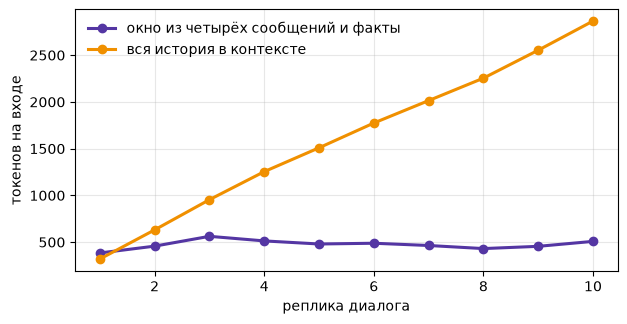

In [201]:
SCRIPT = [t["question"] for t in tasks[0:10]]
for mode in ("память", "вся история"):
    history = []
    for q in SCRIPT:
        talk("bench", history, q, mode)
per_turn = pd.DataFrame([c for c in ledger.calls if c["tag"].startswith("dialog: ")][-2 * len(SCRIPT):])
fig, ax = plt.subplots(figsize=(7, 3.4))
for (tag, part), color in zip(per_turn.groupby("tag", sort=False), [COLORS["violet"], COLORS["amber"]]):
    ax.plot(range(1, len(part) + 1), part["prompt"].values, marker="o", lw=2.2, color=color,
            label={"dialog: память": "окно из четырёх сообщений и факты", "dialog: вся история": "вся история в контексте"}[tag])
ax.set_xlabel("реплика диалога"); ax.set_ylabel("токенов на входе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/memory_tokens.png", dpi=150, bbox_inches="tight")
per_turn.groupby("tag", sort=False).agg(prompt=("prompt", "sum"), cost=("cost", "sum")).round(5)